In [1]:
#!/usr/bin/env python

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime
from isoweek import Week
from cmdstanpy import CmdStanModel
from cmdstanpy import from_csv
import glob

In [2]:
mu = 1/(52 * 80.0)
dt = 1/8.0

In [3]:
csv_files = glob.glob('stan_output/sinusoid_2025/*20250801092152*.csv')  

print(csv_files)

fit = from_csv(csv_files)

['stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_1.csv', 'stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_4.csv', 'stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_2.csv', 'stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_3.csv']


In [4]:
df_draws = fit.draws_pd()
lp = df_draws["lp__"]  # log posterior column
imax = np.argmax(lp)  # index of sample with highest lp__
best_draw = df_draws.iloc[imax]

beta0_draws = df_draws["beta0"].values  
delta_draws = df_draws["delta"].values

gamma = df_draws["gamma"].values[0]

In [8]:
def DiscTimeRate(r, dt):
    return (1 - np.exp(-r*dt))/dt

# Computing eigenvalues:
def eigs(mu, beta0, gamma, delta, dt):
    mu = DiscTimeRate(mu, dt)
    beta = DiscTimeRate(beta0, dt)
    #beta=beta0
    gamma = DiscTimeRate(gamma, dt)
    delta = DiscTimeRate(delta, dt)
    eig1 = -mu
    eig2 = -(((beta + delta) * (delta + mu) + np.emath.sqrt((delta + mu) * (4 * gamma**3 + beta**2 * (delta + mu) + (delta + mu) * (delta + 2 * mu)**2 + 4 * gamma * (delta + mu) * (delta + 3 * mu) + 4 * gamma**2 * (2 * delta + 3 * mu) - 2 * beta * (2 * gamma**2 + 4 * gamma * (delta + mu) + (delta + mu) * (delta + 2 * mu)))))/(2 * (gamma + delta + mu)))
    return eig2

def eigs_continuous(mu, beta, gamma, delta):
    eig1 = -mu
    eig2 = -(((beta + delta) * (delta + mu) + np.emath.sqrt((delta + mu) * (4 * gamma**3 + beta**2 * (delta + mu) + (delta + mu) * (delta + 2 * mu)**2 + 4 * gamma * (delta + mu) * (delta + 3 * mu) + 4 * gamma**2 * (2 * delta + 3 * mu) - 2 * beta * (2 * gamma**2 + 4 * gamma * (delta + mu) + (delta + mu) * (delta + 2 * mu)))))/(2 * (gamma + delta + mu)))
    return eig2

def R0(mu, beta0, gamma, dt):
    mu = DiscTimeRate(mu, dt)
    beta = DiscTimeRate(beta0, dt)
    gamma = DiscTimeRate(gamma, dt)
    return beta/(mu + gamma)

def T_from_omega0(mu, beta, gamma, delta, dt):
    mu = DiscTimeRate(mu, dt)
    beta = DiscTimeRate(beta, dt)
    gamma = DiscTimeRate(gamma, dt)
    delta = DiscTimeRate(delta, dt)
    omega0_sq = (beta - gamma - mu)*(delta + mu)
    Gamma = (beta + delta) * (delta + mu)/(gamma + delta + mu)
    omega0 = np.sqrt(omega0_sq)
    omega_eq = np.sqrt(omega0_sq - Gamma**2/4)
    f0 = omega_eq/(2*np.pi)
    T = 1/f0
    return T

In [9]:
eig_draws = np.array([eigs(mu, b, gamma, d, dt) 
                       for (b, d) in zip(beta0_draws, delta_draws)])
eig_draws_real = np.array([np.real(e) for e in eig_draws])
eig_draws_imag = np.array([np.imag(e) for e in eig_draws])

R0_draws = np.array([R0(mu, b, gamma, dt) 
                       for (b, d) in zip(beta0_draws, delta_draws)])

T_from_omega0_draws = np.array([T_from_omega0(mu, b, gamma, d, dt) 
                       for (b, d) in zip(beta0_draws, delta_draws)])

In [10]:
def get_summary(draws):
    # Using a frequency as an example here,
    # but draws could be any variable
    mean_freq = draws.mean()
    median_freq = np.median(draws)
    lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])
    
    print(f"mean quantity = {mean_freq:.5f}")
    print(f"median quantity = {median_freq:.5f}")
    print(f"95% CI = [{lower_95:.5f}, {upper_95:.5f}]")

In [11]:
get_summary(eig_draws_real)
get_summary(eig_draws_imag)

mean quantity = -0.00202
median quantity = -0.00201
95% CI = [-0.00237, -0.00167]
mean quantity = -0.02404
median quantity = -0.02404
95% CI = [-0.02435, -0.02371]


In [10]:
f1s = -eig_draws_imag
f0 = 1/52
#Ts = (f1s-f0)**(-1) * (1.0/52)
Ts = (f1s/(2*np.pi))**(-1) * (1.0/52)
get_summary(Ts)

mean quantity = 5.02610
median quantity = 5.02555
95% CI = [4.96203, 5.09563]


In [11]:
get_summary(T_from_omega0_draws/52)

mean quantity = 5.02610
median quantity = 5.02555
95% CI = [4.96203, 5.09563]


In [12]:
f1s = -eig_draws_imag
get_summary(f1s)

mean quantity = 0.02404
median quantity = 0.02404
95% CI = [0.02371, 0.02435]


In [14]:
get_summary(eig_draws_imag/eig_draws_real)

mean quantity = 12.02519
median quantity = 11.96449
95% CI = [10.09681, 14.49083]


In [36]:
get_summary(R0_draws)

mean quantity = 1.59802
median quantity = 1.58730
95% CI = [1.45085, 1.81599]


# Clarifying the dependence of the cycle period on epi parameters

In [12]:
import re

def best_draw_to_dict(row):
    """
    Convert a series of Stan draws into a structured dict,
    grouping vector parameters like param[1], param[2], ... into arrays.
    """
    result = {}
    for col in row.index:
        # Attempt to match something like "paramName[123]"
        m = re.match(r"(.*)\[(\d+)\]$", col)
        if m:
            base_name = m.group(1)
            idx = int(m.group(2))  # 1-based index from Stan
            val = row[col]

            if base_name not in result:
                # store them in a dict first, convert to array after.
                result[base_name] = {}
            result[base_name][idx] = val
        else:
            # it is a scalar param or a special column like chain__, iter__, ...
            result[col] = row[col]

    # Convert any dict-of-indices to a list or array
    # Stan uses 1-indexing
    for k, v in list(result.items()):
        if isinstance(v, dict):
            # v is a dictionary of indices -> values
            max_idx = max(v.keys())
            # create an array of length = max index
            arr = np.empty(max_idx, dtype=float)
            for i in range(1, max_idx + 1):
                arr[i - 1] = v[i]  # shift to zero-indexing
            result[k] = arr
    return result

best_draw_dict = best_draw_to_dict(best_draw)


In [13]:
dt_discrete = dt

mu = DiscTimeRate(1/(52 * 80.0), dt_discrete)


beta0 = DiscTimeRate(best_draw_dict['beta0'], dt_discrete)
betaphase = best_draw_dict['betaphase']
gamma = DiscTimeRate(best_draw_dict['gamma'], dt_discrete)
delta = DiscTimeRate(best_draw_dict['delta'], dt_discrete)
S0 = best_draw_dict['S0']
I0 = best_draw_dict['I0']

In [14]:
def get_period(mu, beta0, gamma, delta):
    return np.abs(2*np.pi/(52.0*np.imag(eigs_continuous(mu, beta0, gamma, delta))))

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def label_contours_noclash(CS, min_dist=0.15, fractions_try=None, fontsize=7):
    # Functions to place labels on contours in a somewhat less messy fashion
    # (the matplotlib defaults are no good ... )
    
    if fractions_try is None:
        fractions_try = [0.25, 0.5, 0.75, 0.35, 0.6, 0.15, 0.85]

    positions = []
    label_levels = []
    placed = []  # already placed (x, y)

    def pick_point_on_polyline(verts, frac):
        if verts is None or np.asarray(verts).ndim != 2 or verts.shape[0] == 0:
            return None 
        if verts.shape[0] == 1:
            return verts[0, 0], verts[0, 1]
        diffs = np.diff(verts, axis=0)
        seglen = np.hypot(diffs[:, 0], diffs[:, 1])
        cum = np.concatenate([[0.0], np.cumsum(seglen)])
        total = cum[-1]
        if total <= 0:
            i = len(verts) // 2
            return verts[i, 0], verts[i, 1]
        s = frac * total
        k = np.searchsorted(cum, s, side='right') - 1
        k = np.clip(k, 0, len(verts) - 2)
        t = (s - cum[k]) / max(seglen[k], 1e-12)
        x = verts[k, 0] + t * (verts[k+1, 0] - verts[k, 0])
        y = verts[k, 1] + t * (verts[k+1, 1] - verts[k, 1])
        return x, y

    for idx, L in enumerate(CS.levels):
        segs_raw = CS.allsegs[idx]
        segs = [v for v in segs_raw if v is not None and np.asarray(v).ndim == 2 and v.shape[0] >= 2]
        if not segs:
            continue

        # choose the longest segment for that level
        def poly_length(verts):
            d = np.diff(verts, axis=0)
            return np.hypot(d[:, 0], d[:, 1]).sum()

        verts = max(segs, key=poly_length)

        # try candidate positions along the path until far from existing labels
        chosen = None
        for f in fractions_try:
            pt = pick_point_on_polyline(verts, f)
            if pt is None:
                continue
            x, y = pt
            if all(np.hypot(x - px, y - py) >= min_dist for (px, py) in placed):
                chosen = (x, y)
                break

        if chosen is None:
            # last resort: use midpoint if we didn’t find a spaced-out spot
            pt = pick_point_on_polyline(verts, 0.5)
            if pt is None:
                continue
            chosen = pt

        positions.append(chosen)
        label_levels.append(L)
        placed.append(chosen)

    if positions:
        plt.clabel(CS, levels=label_levels, manual=positions,
                   fmt='%d', colors="black", fontsize=fontsize,
                   inline=True, inline_spacing=8, use_clabeltext=True)


def draw_period_heatmap(xmat, ymat, zmat, x0, y0, xlabel, ylabel, min_dist=0.15):
    plt.figure(figsize=(4,4), dpi=200)
    
    pc = plt.pcolormesh(xmat, ymat, zmat, vmin=0, vmax=10, cmap="inferno", shading='auto')
    
    cbar = plt.colorbar(pc, label="Period (years)", ticks=[0, 2, 4, 6, 8, 10])
    cbar.ax.set_yticklabels([0, 2, 4, 6, 8, "10+"])
    
    levels = np.arange(int(np.ceil(np.min(zmat))), 11, 1)
    CS = plt.contour(xmat,
        ymat,
        zmat,
        levels=levels, colors="black", linewidths=0.8)
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    # Apply the helper
    label_contours_noclash(CS, min_dist=min_dist)
    
    plt.scatter(x0, y0, marker="x", color="black")
    plt.tight_layout()
    plt.show()


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_141726/2029465316.py:16: SyntaxWarning: invalid escape sequence '\m'
  draw_period_heatmap(1/(52*mu_mat), beta_mat, period_mat, 1/(52*mu), beta0, "Avg. lifespan $1/\mu$ (years)", r"Transmission rate $\beta$ (1/week)", min_dist=0.15)
/tmp/ipykernel_141726/1077123024.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(2*np.pi/(52.0*np.imag(eigs_continuous(mu, beta0, gamma, delta))))


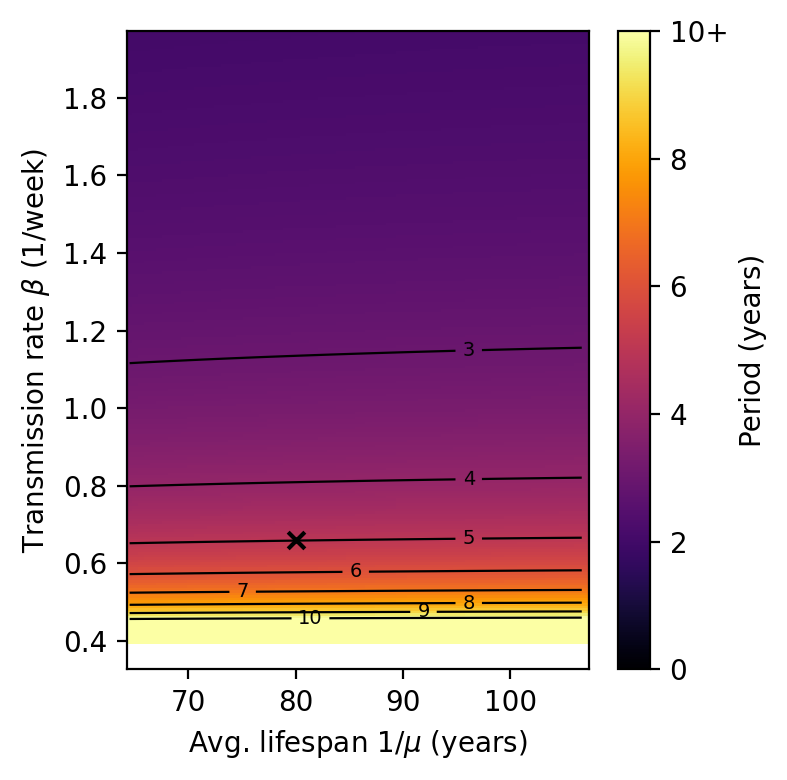

In [17]:
# mu, beta, period heatmap

mus = np.arange(0.75*mu, 1.25*mu, 0.01*mu)
betas = np.arange(0.5*beta0, 3*beta0, 0.01*beta0)

mu_mat = np.zeros((len(mus), len(betas)))
beta_mat = np.zeros((len(mus), len(betas)))
period_mat = np.zeros((len(mus), len(betas)))

for i, mu_loc in enumerate(mus):
    for j, beta_loc in enumerate(betas):
        mu_mat[i,j] = mu_loc
        beta_mat[i,j] = beta_loc
        period_mat[i,j] = get_period(mu_loc, beta_loc, gamma, delta)

draw_period_heatmap(1/(52*mu_mat), beta_mat, period_mat, 1/(52*mu), beta0, "Avg. lifespan $1/\mu$ (years)", r"Transmission rate $\beta$ (1/week)", min_dist=0.15)

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_141726/4037928688.py:16: SyntaxWarning: invalid escape sequence '\m'
  draw_period_heatmap(1/(52*mu_mat), 1/gamma_mat, period_mat, 1/(52*mu), 1/gamma, "Avg. lifespan $1/\mu$ (years)", r"Avg. infectious period $1/\gamma$ (weeks)", min_dist=1)
/tmp/ipykernel_141726/1077123024.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(2*np.pi/(52.0*np.imag(eigs_continuous(mu, beta0, gamma, delta))))


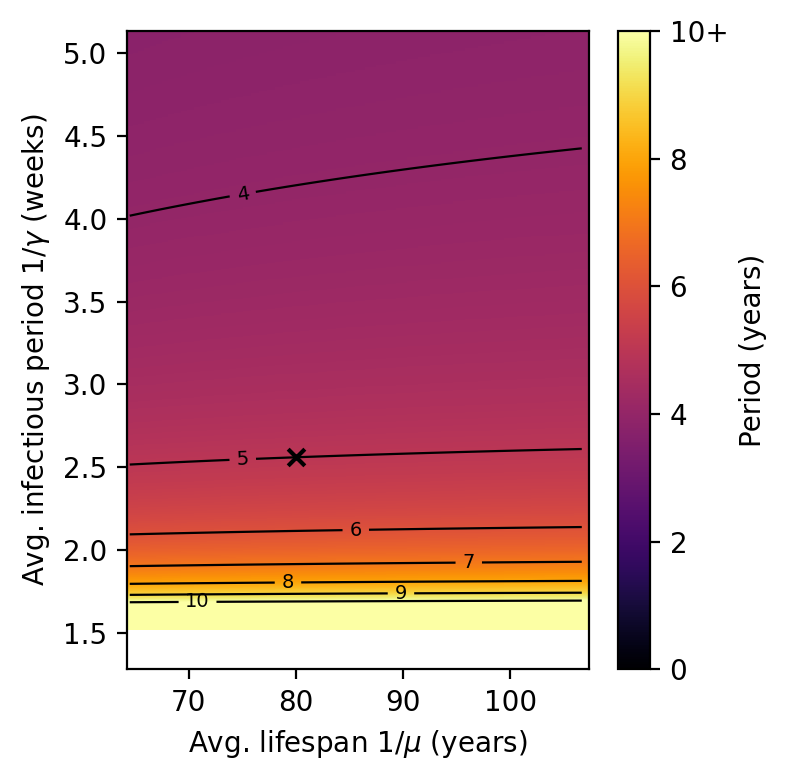

In [18]:
# mu, gamma, period heatmap

mus = np.arange(0.75*mu, 1.25*mu, 0.01*mu)
gammas = np.arange(gamma/2, 2*gamma, gamma/1000)

mu_mat = np.zeros((len(mus), len(gammas)))
gamma_mat = np.zeros((len(mus), len(gammas)))
period_mat = np.zeros((len(mus), len(gammas)))

for i, mu_loc in enumerate(mus):
    for j, gamma_loc in enumerate(gammas):
        mu_mat[i,j] = mu_loc
        gamma_mat[i,j] = gamma_loc
        period_mat[i,j] = get_period(mu_loc, beta0, gamma_loc, delta)

draw_period_heatmap(1/(52*mu_mat), 1/gamma_mat, period_mat, 1/(52*mu), 1/gamma, "Avg. lifespan $1/\mu$ (years)", r"Avg. infectious period $1/\gamma$ (weeks)", min_dist=1)

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_141726/1684466265.py:16: SyntaxWarning: invalid escape sequence '\m'
  draw_period_heatmap(1/(52*mu_mat), 1/(52*delta_mat), period_mat, 1/(52*mu), 1/(52*delta), "Avg. lifespan $1/\mu$ (years)", r"Avg. immunity duration $1/\delta$ (years)", min_dist=1)


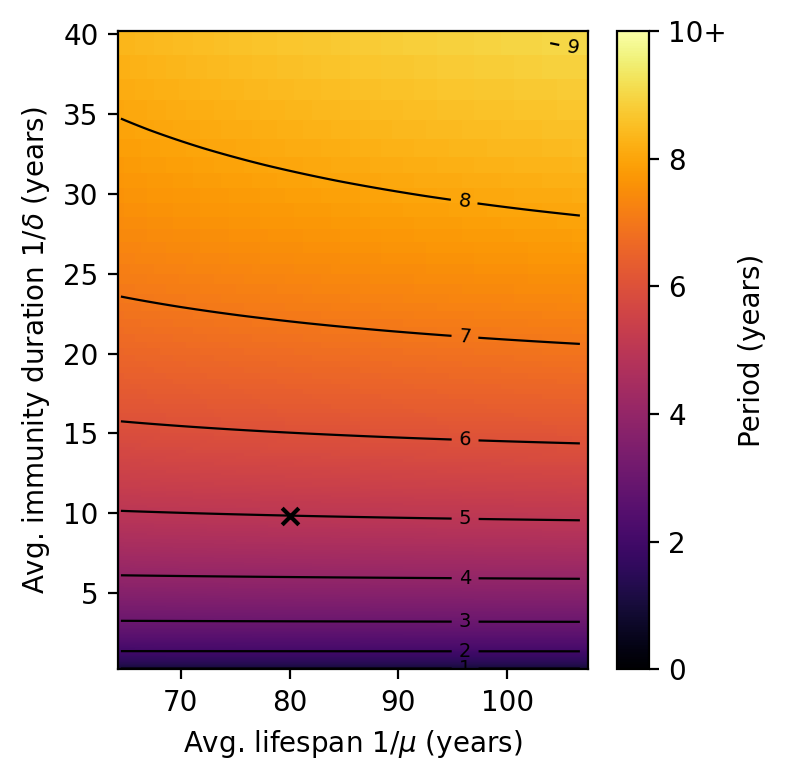

In [19]:
# mu, delta, period heatmap

mus = np.arange(0.75*mu, 1.25*mu, 0.01*mu)
deltas = np.arange(delta/4, 40*delta, delta/100)

mu_mat = np.zeros((len(mus), len(deltas)))
delta_mat = np.zeros((len(mus), len(deltas)))
period_mat = np.zeros((len(mus), len(deltas)))

for i, mu_loc in enumerate(mus):
    for j, delta_loc in enumerate(deltas):
        mu_mat[i,j] = mu_loc
        delta_mat[i,j] = delta_loc
        period_mat[i,j] = get_period(mu_loc, beta0, gamma, delta_loc)

draw_period_heatmap(1/(52*mu_mat), 1/(52*delta_mat), period_mat, 1/(52*mu), 1/(52*delta), "Avg. lifespan $1/\mu$ (years)", r"Avg. immunity duration $1/\delta$ (years)", min_dist=1)

/tmp/ipykernel_141726/1077123024.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(2*np.pi/(52.0*np.imag(eigs_continuous(mu, beta0, gamma, delta))))


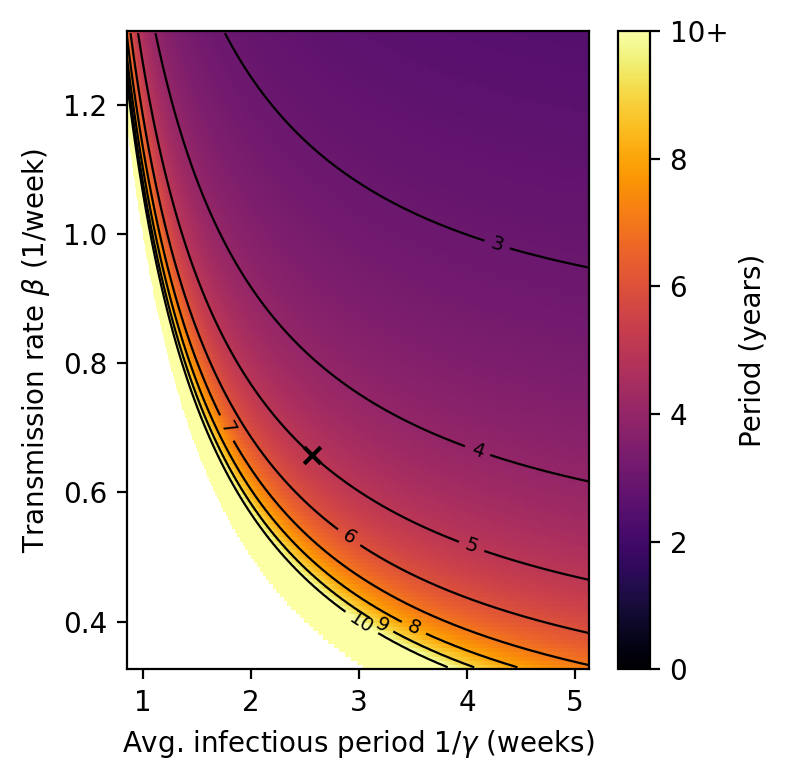

In [20]:
# gamma, beta, period heatmap

gammas = np.arange(gamma/2, 3*gamma, gamma/1000)
betas = np.arange(0.5*beta0, 2*beta0, 0.01*beta0)

gamma_mat = np.zeros((len(gammas), len(betas)))
beta_mat = np.zeros((len(gammas), len(betas)))
period_mat = np.zeros((len(gammas), len(betas)))

for i, gamma_loc in enumerate(gammas):
    for j, beta_loc in enumerate(betas):
        gamma_mat[i,j] = gamma_loc
        beta_mat[i,j] = beta_loc
        period_mat[i,j] = get_period(mu, beta_loc, gamma_loc, delta)

draw_period_heatmap(1/gamma_mat, beta_mat, period_mat, 1/gamma, beta0, r"Avg. infectious period $1/\gamma$ (weeks)", r"Transmission rate $\beta$ (1/week)", min_dist=0.15)

In [21]:
# delta, beta, period heatmap

deltas = np.arange(delta/4, 40*delta, delta/100)
betas = np.arange(0.5*beta0, 2*beta0, 0.01*beta0)

delta_mat = np.zeros((len(deltas), len(betas)))
beta_mat = np.zeros((len(deltas), len(betas)))
period_mat = np.zeros((len(deltas), len(betas)))

for i, delta_loc in enumerate(deltas):
    for j, beta_loc in enumerate(betas):
        delta_mat[i,j] = delta_loc
        beta_mat[i,j] = beta_loc
        period_mat[i,j] = get_period(mu, beta_loc, gamma, delta_loc)

/tmp/ipykernel_141726/1077123024.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(2*np.pi/(52.0*np.imag(eigs_continuous(mu, beta0, gamma, delta))))


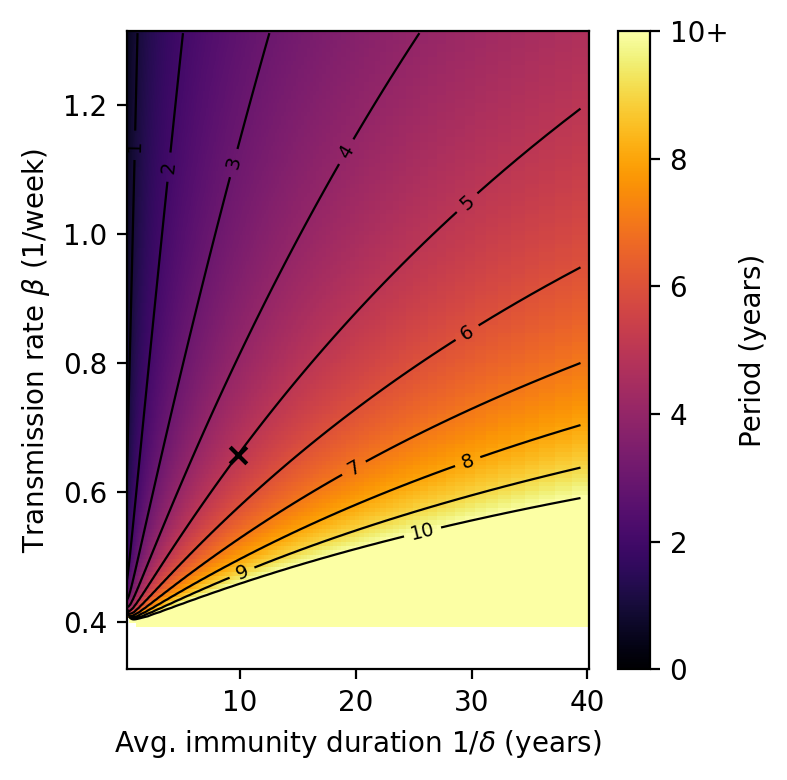

In [22]:
draw_period_heatmap(1/(52*delta_mat), beta_mat, period_mat, 1/(52*delta), beta0, r"Avg. immunity duration $1/\delta$ (years)", r"Transmission rate $\beta$ (1/week)", min_dist=0.15)

In [23]:
# gamma, delta, period heatmap

gammas = np.arange(gamma/2, 3*gamma, gamma/1000)
deltas = np.arange(delta/4, 40*delta, delta/100)

gamma_mat = np.zeros((len(gammas), len(deltas)))
delta_mat = np.zeros((len(gammas), len(deltas)))
period_mat = np.zeros((len(gammas), len(deltas)))

for i, gamma_loc in enumerate(gammas):
    for j, delta_loc in enumerate(deltas):
        gamma_mat[i,j] = gamma_loc
        delta_mat[i,j] = delta_loc
        period_mat[i,j] = get_period(mu, beta0, gamma_loc, delta_loc)

/tmp/ipykernel_141726/1077123024.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(2*np.pi/(52.0*np.imag(eigs_continuous(mu, beta0, gamma, delta))))


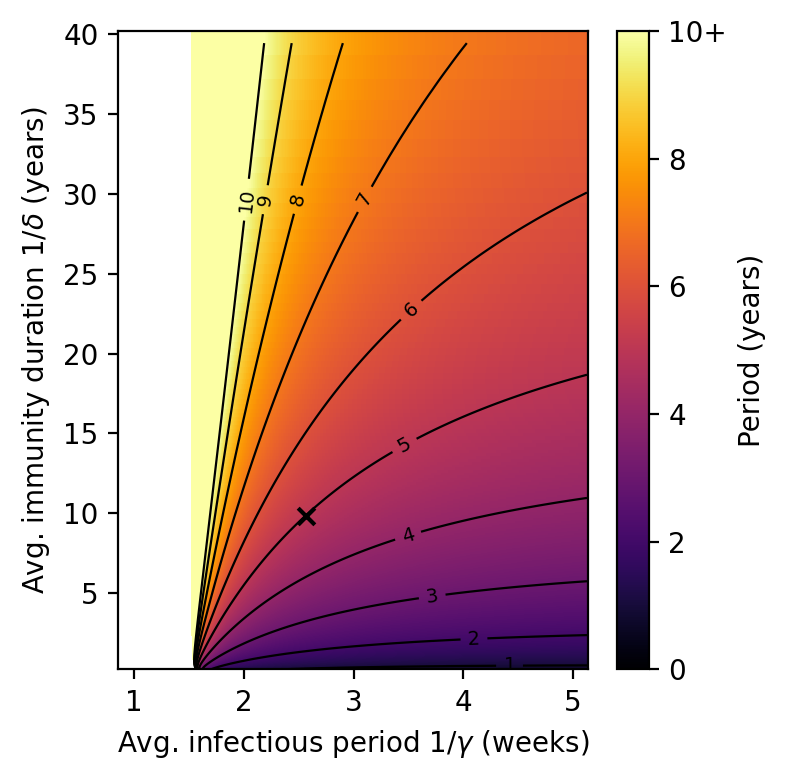

In [24]:
draw_period_heatmap(1/gamma_mat, 1/(52*delta_mat), period_mat, 1/gamma, 1/(52*delta), r"Avg. infectious period $1/\gamma$ (weeks)", r"Avg. immunity duration $1/\delta$ (years)", min_dist=0.15)